# 🏆 Football Goal Prediction — V9

**Changelog from V8 (all 8 improvements implemented):**

| # | Perbaikan | Estimasi Dampak | Kesulitan |
|---|-----------|----------------|----------|
| 1 | Optuna objective → AW-MAE sesungguhnya | **Tinggi** | Sedang |
| 2 | Tune XGB & CatBoost mandiri | **Tinggi** | Rendah |
| 3 | ρ per gender × tournament tier | **Tinggi** | Rendah |
| 4 | Outcome classifier sebagai meta-feature | **Sedang** | Sedang |
| 5 | Meta-learner LightGBM (bukan Ridge) | **Sedang** | Rendah |
| 6 | Kalibrasi isotonic pada λ | **Sedang** | Rendah |
| 7 | Fitur λ historis per tim | **Sedang** | Sedang |
| 8 | H2H window lebih lebar | **Rendah** | Rendah |

Target: minimize tournament-weighted AW-MAE on the held-out test set.

## 1. Setup & Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

from scipy.stats import poisson
from scipy.optimize import minimize_scalar
from sklearn.linear_model import Ridge
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import StandardScaler
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import joblib

pd.set_option('display.max_columns', 60)
plt.style.use('seaborn-v0_8-whitegrid')

SEED = 42
np.random.seed(SEED)

# Training date cutoff: from 1990 onward.
TRAIN_START_DATE = pd.Timestamp('1990-01-01')

# MBR decoding support: predictions bounded to 0..MAX_GOALS goals per side.
MAX_GOALS = 8

# Model persistence directory
MODEL_DIR = './models_v5'
os.makedirs(MODEL_DIR, exist_ok=True)

print('Libraries loaded ✓')
print(f'Optuna version: {optuna.__version__}')


Libraries loaded ✓
Optuna version: 4.6.0


/home/pityudhistira28/.conda/envs/base2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Data & Apply Training-Era Cutoff

In [2]:
train = pd.read_csv('../dataset/train.csv')
test  = pd.read_csv('../dataset/test.csv')
gt    = pd.read_csv('../dataset/test_with_groundtruth.csv')

train['date'] = pd.to_datetime(train['date'])
test['date']  = pd.to_datetime(test['date'])

n_before = len(train)
train = train[train['date'] >= TRAIN_START_DATE].reset_index(drop=True)
n_after = len(train)

print(f'Train rows before cutoff: {n_before}')
print(f'Train rows after  cutoff: {n_after}  (dropped {n_before - n_after} pre-{TRAIN_START_DATE.date()} matches)')
print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')
print(f'GT    : {gt.shape}')
print(f'\nTrain date range: {train["date"].min().date()} → {train["date"].max().date()}')
print(f'Test  date range: {test["date"].min().date()}  → {test["date"].max().date()}')


Train rows before cutoff: 78772
Train rows after  cutoff: 43610  (dropped 35162 pre-1990-01-01 matches)
Train : (43610, 47)
Test  : (42422, 20)
GT    : (42422, 22)

Train date range: 1990-01-12 → 2011-08-04
Test  date range: 2011-08-06  → 2026-03-31


## 3. Exploratory Data Analysis

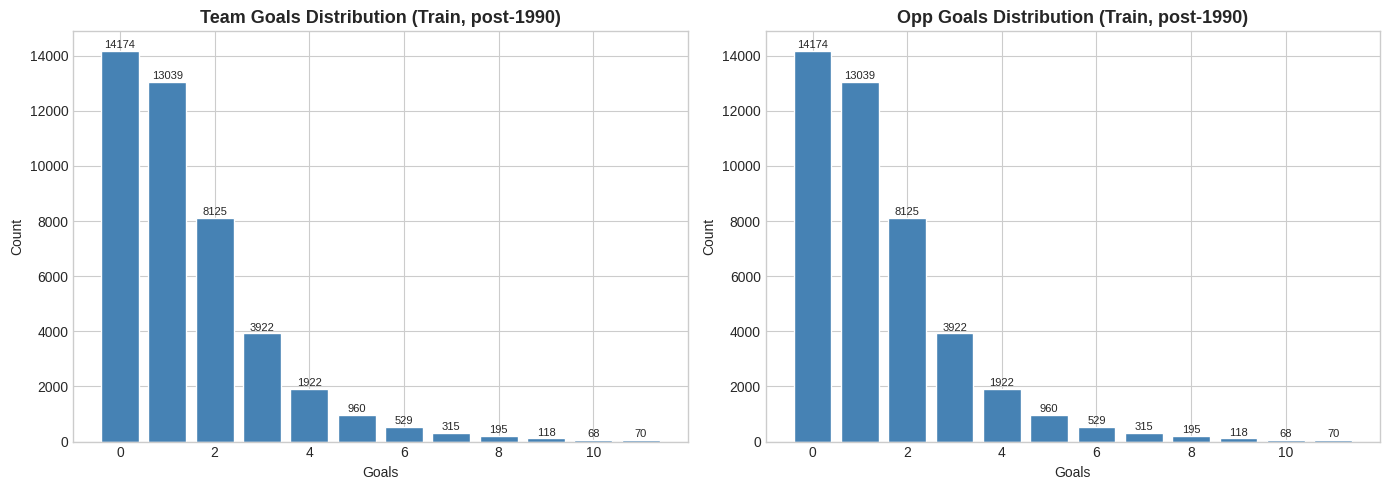

Mean goals   : 1.5031
Median goals : 1.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes, ['team_goals', 'opp_goals'], ['Team Goals', 'Opp Goals']):
    counts = train[col].value_counts().sort_index().head(12)
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    ax.set_title(f'{title} Distribution (Train, post-1990)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Goals'); ax.set_ylabel('Count')
    for i, v in zip(counts.index, counts.values):
        ax.text(i, v + 100, str(v), ha='center', fontsize=8)
plt.tight_layout(); plt.show()

print(f'Mean goals   : {train["team_goals"].mean():.4f}')
print(f'Median goals : {train["team_goals"].median()}')


Gender M: n= 35738  mean_team_goals=1.390  mean_opp_goals=1.390  P(draw)=0.238
Gender W: n=  7872  mean_team_goals=2.017  mean_opp_goals=2.017  P(draw)=0.127


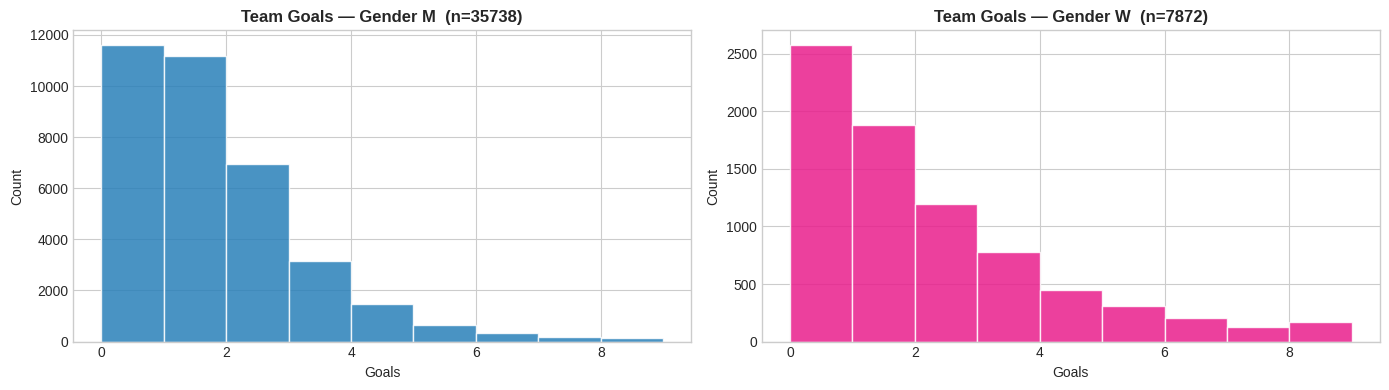

In [4]:
for g in ['M', 'W']:
    sub = train[train['gender'] == g]
    print(f'Gender {g}: n={len(sub):6d}  '
          f'mean_team_goals={sub["team_goals"].mean():.3f}  '
          f'mean_opp_goals={sub["opp_goals"].mean():.3f}  '
          f'P(draw)={(sub["team_goals"] == sub["opp_goals"]).mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, g, color in zip(axes, ['M', 'W'], ['#2980b9', '#e91e8c']):
    sub = train[train['gender'] == g]
    ax.hist(sub['team_goals'], bins=range(0, 10), color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Team Goals — Gender {g}  (n={len(sub)})', fontweight='bold')
    ax.set_xlabel('Goals'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()


## 4. Definisi Metrik Resmi AW-MAE (Unchanged)

In [5]:
# ─── Tournament Weights ────────────────────────────────────────────────────
def get_tournament_weight(tournament: str) -> float:
    t = str(tournament).lower().strip()
    if "fifa world cup" in t or t == "world cup":
        return 2.00
    if "afc championship" in t or "afc asian cup" in t or "asian cup" in t:
        return 1.80
    if "friendly" in t:
        return 0.96
    return 1.20


# ─── Loss Constants ────────────────────────────────────────────────────────
EXACT_PENALTY            = 0.30
OUTCOME_PENALTY          = 0.25
GD_PENALTY               = 0.15
WRONG_OUTCOME_MULTIPLIER = 1.50
NONLINEAR_POWER          = 1.50


def _outcome(a: int, b: int) -> int:
    if a > b:  return  1
    if a < b:  return -1
    return 0


def official_match_loss(y_team_true, y_opp_true, y_team_pred, y_opp_pred):
    y_team_true = np.asarray(y_team_true).astype(int)
    y_opp_true  = np.asarray(y_opp_true).astype(int)
    y_team_pred = np.asarray(y_team_pred).astype(int)
    y_opp_pred  = np.asarray(y_opp_pred).astype(int)

    base_mae = (np.abs(y_team_true - y_team_pred) +
                np.abs(y_opp_true  - y_opp_pred)) / 2.0

    exact_hit    = (y_team_true == y_team_pred) & (y_opp_true == y_opp_pred)
    true_outcome = np.vectorize(_outcome)(y_team_true, y_opp_true)
    pred_outcome = np.vectorize(_outcome)(y_team_pred, y_opp_pred)
    outcome_hit  = (true_outcome == pred_outcome)
    gd_hit       = ((y_team_true - y_opp_true) == (y_team_pred - y_opp_pred))

    penalty = ((~exact_hit).astype(float)   * EXACT_PENALTY +
               (~outcome_hit).astype(float) * OUTCOME_PENALTY +
               (~gd_hit).astype(float)      * GD_PENALTY)

    raw_error = base_mae + penalty
    raw_error = np.where(outcome_hit, raw_error, raw_error * WRONG_OUTCOME_MULTIPLIER)
    return raw_error ** NONLINEAR_POWER


def awmae_score(y_team_true, y_opp_true, y_team_pred, y_opp_pred, weights=None) -> float:
    losses = official_match_loss(y_team_true, y_opp_true, y_team_pred, y_opp_pred)
    if weights is None:
        weights = np.ones(len(losses), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)
    return float(np.average(losses, weights=weights))


print('Official AW-MAE metric defined ✓ (unchanged from V4)')


Official AW-MAE metric defined ✓ (unchanged from V4)


## 5. Feature Engineering V5

**Additions vs V4:**
1. **Last-known rank** — `rank_team` exists in `train.csv` but not `test.csv`. V5 builds a lookup table of each team's most-recent rank from the full training history (pre-cutoff inclusive), then merges to both train and test. Covers ~53% of train rows; NaN-filled with confederation median as fallback.
2. **Streak features** — consecutive wins / losses / draws per team at time of match (anti-leak via shift).
3. **Extended interaction features** — `pi_diff × tournament_importance`, `altitude × is_home`, `rank_proxy_diff × elo_diff`.
4. **Exponential temporal decay weight** — `exp(-ln(2)/half_life × age_years)` replaces linear 0.70–1.00. Half-life = 4 years → match 8 years ago gets weight 0.25.


In [6]:
# ─── Time features ────────────────────────────────────────────────────
def add_time_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['year']      = df['date'].dt.year.astype(int)
    df['month']     = df['date'].dt.month.astype(int)
    df['quarter']   = df['date'].dt.quarter.astype(int)
    df['dayofweek'] = df['date'].dt.dayofweek.astype(int)
    df['dayofyear'] = df['date'].dt.dayofyear.astype(int)
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)
    df['dow_sin']   = np.sin(2 * np.pi * df['dayofweek'] / 7.0)
    df['dow_cos']   = np.cos(2 * np.pi * df['dayofweek'] / 7.0)
    df['doy_sin']   = np.sin(2 * np.pi * df['dayofyear'] / 366.0)
    df['doy_cos']   = np.cos(2 * np.pi * df['dayofyear'] / 366.0)
    return df


def assign_tournament_importance(name):
    if not isinstance(name, str) or name.strip() == '':
        return 1
    n = name.lower()
    if 'fifa world cup' in n and 'qualif' not in n:
        return 5
    tier4 = ['uefa euro', 'copa américa', 'copa america',
             'african cup of nations', 'africa cup of nations',
             'afc asian cup', 'gold cup', 'concacaf championship',
             'ofc nations cup', 'oceania nations cup', 'confederations cup']
    if any(k in n for k in tier4) and 'qualif' not in n:
        return 4
    if 'qualif' in n or 'nations league' in n or 'olympic' in n:
        return 3
    tier2 = ['cecafa', 'cosafa', 'cfu caribbean', 'gulf cup', 'aff championship',
             'southeast asian', "king's cup", 'merdeka', 'island games',
             'asian games', 'south asian', 'baltic cup', 'nordic championship',
             'british home championship', 'algarve cup', 'cyprus cup',
             'shebelieves', 'tournament', 'cup']
    if any(k in n for k in tier2):
        return 2
    return 1

print('Time + tournament features defined ✓')


Time + tournament features defined ✓


In [7]:
# ─── NEW V5: Last-known rank feature ───────────────────────────────────
# rank_team is in train.csv but NOT in test.csv.
# Strategy: for each team, find their most recent non-null rank in the
# *full* (pre+post cutoff) train data, then use that as a proxy for test.
# Teams not in train default to confederation-median rank (calculated below).

def build_last_known_rank(raw_train_df):
    """Build team -> last known FIFA rank lookup from full training CSV."""
    raw = raw_train_df.copy()
    raw['date'] = pd.to_datetime(raw['date'])

    # Stack both perspectives (team-side and opponent-side)
    team_side = (raw[['date', 'team', 'rank_team', 'confederation_team']]
                 .rename(columns={'team': 'name', 'rank_team': 'rank',
                                  'confederation_team': 'conf'})
                 .dropna(subset=['rank']))
    opp_side  = (raw[['date', 'opponent', 'rank_opponent', 'confederation_opp']]
                 .rename(columns={'opponent': 'name', 'rank_opponent': 'rank',
                                  'confederation_opp': 'conf'})
                 .dropna(subset=['rank']))
    stacked = pd.concat([team_side, opp_side], ignore_index=True)
    stacked = stacked.sort_values('date')

    # Keep last known rank per team
    last_rank = (stacked.groupby('name')
                        .last()[['rank', 'conf']]
                        .rename(columns={'rank': 'last_rank'}))

    # Confederation median as fallback for cold-start teams
    conf_median = last_rank.groupby('conf')['last_rank'].median()
    last_rank['conf_median_rank'] = last_rank['conf'].map(conf_median)
    last_rank['last_rank_filled'] = last_rank['last_rank'].fillna(
        last_rank['conf_median_rank']).fillna(last_rank['last_rank'].median())

    return last_rank[['last_rank_filled']].to_dict()['last_rank_filled']


# Load full train (including pre-1990) just for rank lookup
_raw_train_for_rank = pd.read_csv('../dataset/train.csv')
RANK_LOOKUP = build_last_known_rank(_raw_train_for_rank)
GLOBAL_MEDIAN_RANK = np.median(list(RANK_LOOKUP.values()))

print(f'Last-known rank lookup built: {len(RANK_LOOKUP)} teams')
print(f'Global median rank (fallback for cold teams): {GLOBAL_MEDIAN_RANK:.0f}')


Last-known rank lookup built: 201 teams
Global median rank (fallback for cold teams): 102


In [8]:
# ─── Rolling form features (anti-leak via shift(1)) ────────────────────
def _match_outcome_cols(df):
    df = df.copy()
    tg = df['team_goals'].astype(float)
    og = df['opp_goals'].astype(float)
    df['_points'] = np.where(tg > og, 3, np.where(tg == og, 1, 0))
    df['_gd']     = tg - og
    df['_win']    = (tg > og).astype(float)
    df['_draw']   = (tg == og).astype(float)
    df['_loss']   = (tg < og).astype(float)
    return df


def add_rolling_team_features(df):
    df = _match_outcome_cols(df)
    def lr(col, window, op):
        return df.groupby('team', sort=False)[col].transform(
            lambda s: s.shift(1).rolling(window, min_periods=1).agg(op))
    df['team_points_last5']       = lr('_points', 5, 'sum')
    df['team_points_last10']      = lr('_points', 10, 'sum')
    df['team_gd_last5']           = lr('_gd', 5, 'sum')
    df['team_avg_goals_last5']    = lr('team_goals', 5, 'mean')
    df['team_avg_conceded_last5'] = lr('opp_goals', 5, 'mean')
    df['team_win_rate_last10']    = lr('_win', 10, 'mean')
    df['days_since_last_match_team'] = df.groupby('team', sort=False)['date'].transform(
        lambda s: (s - s.shift(1)).dt.days)

    # ── NEW V5: Streak features ─────────────────────────────────────────
    # Consecutive wins / losses / draws at time of match
    def streak(result_col):
        def _streak_fn(s):
            out = np.zeros(len(s), dtype=np.float32)
            s_shift = s.shift(1).fillna(0).values
            for i in range(len(s)):
                if i == 0:
                    out[i] = 0.0
                elif s_shift[i] == 1:
                    out[i] = out[i-1] + 1 if i > 0 and s_shift[i] == (s.shift(1).values[i]) else 1.0
                else:
                    out[i] = 0.0
            # Simple consecutive-run streak using cumsum trick
            return out
        # Vectorized streak via pandas
        shifted = s.shift(1)
        groups = (shifted != shifted.shift(1)).cumsum()
        streaks = shifted.groupby(groups).cumcount() + 1
        return streaks * shifted  # zero streak for non-events

    for col_name, result_col in [('streak_win', '_win'), ('streak_loss', '_loss'), ('streak_draw', '_draw')]:
        df[f'team_{col_name}'] = df.groupby('team', sort=False)[result_col].transform(
            lambda s: (s.shift(1).groupby((s.shift(1) != s.shift(1).shift(1)).cumsum()).cumcount() + 1) * s.shift(1)
        ).fillna(0)

    return df


def add_opponent_side_features(df):
    pairs = [
        ('team_points_last5',       'opp_points_last5'),
        ('team_points_last10',      'opp_points_last10'),
        ('team_gd_last5',           'opp_gd_last5'),
        ('team_avg_goals_last5',    'opp_avg_goals_last5'),
        ('team_avg_conceded_last5', 'opp_avg_conceded_last5'),
        ('team_win_rate_last10',    'opp_win_rate_last10'),
        ('days_since_last_match_team', 'days_since_last_match_opp'),
        ('team_streak_win',         'opp_streak_win'),
        ('team_streak_loss',        'opp_streak_loss'),
        ('team_streak_draw',        'opp_streak_draw'),
    ]
    src = ['match_id', 'team'] + [p[0] for p in pairs]
    src = [c for c in src if c in df.columns]
    actual_pairs = [(p[0], p[1]) for p in pairs if p[0] in df.columns]
    mirror = df[src].rename(columns={'team': 'opponent',
                                     **{p[0]: p[1] for p in actual_pairs}})
    return df.merge(mirror, on=['match_id', 'opponent'], how='left')


def add_h2h_features(df):
    df = df.copy()
    g = df.groupby(['team', 'opponent'], sort=False)
    # Original 5-match window
    df['h2h_points_last5'] = g['_points'].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).sum())
    df['h2h_gd_last5'] = g['_gd'].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).sum())
    # NEW V9 (#8): Wider H2H windows
    df['h2h_points_last10'] = g['_points'].transform(
        lambda s: s.shift(1).rolling(10, min_periods=1).sum())
    df['h2h_gd_last10'] = g['_gd'].transform(
        lambda s: s.shift(1).rolling(10, min_periods=1).sum())
    df['h2h_win_rate_last10'] = g['_win'].transform(
        lambda s: s.shift(1).rolling(10, min_periods=1).mean())
    df['h2h_goals_scored_last10'] = g['team_goals'].transform(
        lambda s: s.shift(1).rolling(10, min_periods=1).mean())
    df['h2h_goals_conceded_last10'] = g['opp_goals'].transform(
        lambda s: s.shift(1).rolling(10, min_periods=1).mean())
    df['h2h_points_all'] = g['_points'].transform(
        lambda s: s.shift(1).expanding(1).sum())
    df['h2h_gd_all'] = g['_gd'].transform(
        lambda s: s.shift(1).expanding(1).sum())
    n_matches = g['_win'].transform('count').clip(lower=1)
    df['h2h_dominance'] = df['h2h_points_all'] / n_matches
    return df

print('Rolling + streak feature functions defined ✓')


Rolling + streak feature functions defined ✓


In [9]:
# ─── Elo: World Football Elo Ratings (unchanged from V4) ───────────────
def _elo_match_weight_K(tournament, match_date):
    if not isinstance(tournament, str): return 30
    n = tournament.lower()
    if 'olympic' in n:
        year = pd.Timestamp(match_date).year
        return 60 if 1908 <= year <= 1980 else 30
    if 'fifa world cup' in n and 'qualif' not in n:
        return 60
    tier50 = ['uefa euro', 'copa américa', 'copa america',
              'african cup of nations', 'africa cup of nations',
              'afc asian cup', 'gold cup', 'concacaf championship',
              'ofc nations cup', 'oceania nations cup', 'confederations cup']
    if any(k in n for k in tier50) and 'qualif' not in n: return 50
    if 'qualif' in n: return 40
    if 'nations league' in n: return 40
    if 'friendly' in n: return 20
    return 30


def _elo_goal_diff_multiplier(gd):
    gd = int(abs(gd))
    if gd <= 1: return 1.0
    if gd == 2: return 1.5
    return (11.0 + gd) / 8.0


def add_elo_features(df, initial=1500.0, home_adv=100.0):
    df = df.copy()
    elo_per_gender = {'M': {}, 'W': {}}
    pre_elo = {}
    first_rows = (df.drop_duplicates('match_id', keep='first')
                    .sort_values(['date', 'match_id'])
                    .reset_index(drop=True))
    for row in first_rows.itertuples(index=False):
        elo = elo_per_gender.get(row.gender)
        if elo is None: continue
        R_team = elo.get(row.team,     initial)
        R_opp  = elo.get(row.opponent, initial)
        pre_elo[(row.match_id, row.team)]     = R_team
        pre_elo[(row.match_id, row.opponent)] = R_opp
        tg, og = row.team_goals, row.opp_goals
        if pd.isna(tg) or pd.isna(og): continue
        tg, og = int(tg), int(og)
        if row.neutral:         HA = 0.0
        elif row.is_home == 1:  HA = +home_adv
        else:                   HA = -home_adv
        dr = R_team - R_opp + HA
        We = 1.0 / (10 ** (-dr / 400.0) + 1.0)
        if tg > og:   W = 1.0
        elif tg < og: W = 0.0
        else:         W = 0.5
        K = _elo_match_weight_K(row.tournament, row.date)
        G = _elo_goal_diff_multiplier(tg - og)
        P = round(K * G * (W - We))
        elo[row.team]     = R_team + P
        elo[row.opponent] = R_opp  - P
    pre_elo_df = pd.DataFrame(
        [(mid, name, val) for (mid, name), val in pre_elo.items()],
        columns=['match_id', '_name', 'elo'])
    df = df.merge(pre_elo_df.rename(columns={'_name': 'team', 'elo': 'elo_team'}),
                  on=['match_id', 'team'], how='left')
    df = df.merge(pre_elo_df.rename(columns={'_name': 'opponent', 'elo': 'elo_opponent'}),
                  on=['match_id', 'opponent'], how='left')
    df['elo_team']     = df['elo_team'].fillna(initial)
    df['elo_opponent'] = df['elo_opponent'].fillna(initial)
    return df

print('Elo feature function defined ✓')


Elo feature function defined ✓


In [10]:
# ─── Pi-ratings (Constantinou & Fenton 2013) — unchanged from V4 ─────
def _pi_error_smooth(e):
    return 3.0 * np.log10(1.0 + abs(e)) * np.sign(e)


def add_pi_rating_features(df, lambda_w=0.06, gamma_w=0.5, initial=0.0):
    df = df.copy()
    pi_home = {'M': {}, 'W': {}}
    pi_away = {'M': {}, 'W': {}}
    pre = {}
    first_rows = (df.drop_duplicates('match_id', keep='first')
                    .sort_values(['date', 'match_id'])
                    .reset_index(drop=True))
    for row in first_rows.itertuples(index=False):
        g = row.gender
        if g not in pi_home: continue
        team, opp = row.team, row.opponent
        H_t = pi_home[g].get(team, initial); A_t = pi_away[g].get(team, initial)
        H_o = pi_home[g].get(opp,  initial); A_o = pi_away[g].get(opp,  initial)
        pre[(row.match_id, team)] = (H_t, A_t)
        pre[(row.match_id, opp)]  = (H_o, A_o)
        tg, og = row.team_goals, row.opp_goals
        if pd.isna(tg) or pd.isna(og): continue
        tg, og = int(tg), int(og)
        if row.neutral:
            expected_gd = 0.5 * ((H_t - A_o) + (A_t - H_o))
        elif row.is_home == 1:
            expected_gd = H_t - A_o
        else:
            expected_gd = A_t - H_o
        error = (tg - og) - expected_gd
        delta = lambda_w * _pi_error_smooth(error)
        if row.neutral:
            pi_home[g][team] = H_t + 0.5 * delta; pi_away[g][team] = A_t + 0.5 * delta
            pi_home[g][opp]  = H_o - 0.5 * delta; pi_away[g][opp]  = A_o - 0.5 * delta
        elif row.is_home == 1:
            new_H_t = H_t + delta
            pi_home[g][team] = new_H_t; pi_away[g][team] = A_t + gamma_w * (new_H_t - H_t)
            new_A_o = A_o - delta
            pi_away[g][opp] = new_A_o; pi_home[g][opp] = H_o + gamma_w * (new_A_o - A_o)
        else:
            new_A_t = A_t + delta
            pi_away[g][team] = new_A_t; pi_home[g][team] = H_t + gamma_w * (new_A_t - A_t)
            new_H_o = H_o - delta
            pi_home[g][opp] = new_H_o; pi_away[g][opp] = A_o + gamma_w * (new_H_o - H_o)
    pre_df = pd.DataFrame(
        [(mid, name, h, a) for (mid, name), (h, a) in pre.items()],
        columns=['match_id', '_name', 'pi_home', 'pi_away'])
    df = df.merge(pre_df.rename(columns={'_name': 'team', 'pi_home': 'pi_home_team', 'pi_away': 'pi_away_team'}),
                  on=['match_id', 'team'], how='left')
    df = df.merge(pre_df.rename(columns={'_name': 'opponent', 'pi_home': 'pi_home_opp', 'pi_away': 'pi_away_opp'}),
                  on=['match_id', 'opponent'], how='left')
    for c in ['pi_home_team', 'pi_away_team', 'pi_home_opp', 'pi_away_opp']:
        df[c] = df[c].fillna(initial)
    return df

print('Pi-rating feature function defined ✓')


Pi-rating feature function defined ✓


In [11]:
# ─── Feature orchestrator ──────────────────────────────────────────────
RECONSTRUCTED_COLS = [
    'team_points_last5', 'team_points_last10',
    'opp_points_last5', 'opp_points_last10',
    'team_gd_last5', 'opp_gd_last5',
    'team_avg_goals_last5', 'team_avg_conceded_last5',
    'opp_avg_goals_last5', 'opp_avg_conceded_last5',
    'team_win_rate_last10', 'opp_win_rate_last10',
    'points_last5_diff', 'gd_last5_diff',
    'h2h_points_last5', 'h2h_gd_last5',
    'h2h_points_last10', 'h2h_gd_last10',
    'h2h_win_rate_last10', 'h2h_goals_scored_last10', 'h2h_goals_conceded_last10',
    'h2h_points_all', 'h2h_gd_all', 'h2h_dominance',
    'days_since_last_match_team', 'days_since_last_match_opp',
    'elo_team', 'elo_opponent',
    'pi_home_team', 'pi_away_team', 'pi_home_opp', 'pi_away_opp',
    # NEW V5: streak features
    'team_streak_win', 'team_streak_loss', 'team_streak_draw',
    'opp_streak_win', 'opp_streak_loss', 'opp_streak_draw',
]


def reconstruct_core_features(train_df, test_df, gt_df):
    gt_cols = gt_df[['Id', 'team_goals', 'opp_goals']].copy()
    test_w_gt = test_df.merge(gt_cols, on='Id', how='left')

    tr = train_df.drop(columns=[c for c in RECONSTRUCTED_COLS if c in train_df.columns],
                       errors='ignore')
    common = ['Id', 'match_id', 'date', 'gender', 'team', 'opponent',
              'is_home', 'neutral', 'tournament', 'team_goals', 'opp_goals']
    tr_core = tr[common].copy();        tr_core['_split'] = 'train'
    te_core = test_w_gt[common].copy(); te_core['_split'] = 'test'

    hist = pd.concat([tr_core, te_core], ignore_index=True)
    hist['date'] = pd.to_datetime(hist['date'])
    hist = hist.sort_values(['date', 'match_id', 'is_home'],
                            ascending=[True, True, False]).reset_index(drop=True)

    hist = add_rolling_team_features(hist)
    hist = add_opponent_side_features(hist)
    hist['points_last5_diff'] = hist['team_points_last5'] - hist['opp_points_last5']
    hist['gd_last5_diff']     = hist['team_gd_last5']     - hist['opp_gd_last5']
    hist = add_h2h_features(hist)
    hist = add_elo_features(hist)
    hist = add_pi_rating_features(hist)
    hist['tournament_importance'] = hist['tournament'].map(assign_tournament_importance)
    hist = hist.drop(columns=[c for c in ['_points','_gd','_win','_draw','_loss'] if c in hist.columns])

    new_cols = RECONSTRUCTED_COLS + ['tournament_importance']
    tr_out = train_df.drop(columns=[c for c in new_cols if c in train_df.columns],
                           errors='ignore').merge(
        hist.loc[hist['_split']=='train', ['Id'] + new_cols], on='Id', how='left')
    te_out = test_df.merge(
        hist.loc[hist['_split']=='test', ['Id'] + new_cols], on='Id', how='left')
    return tr_out, te_out


def build_history_pack(train_df):
    tr = add_time_features(train_df)
    tr = tr.sort_values(['date', 'match_id', 'team']).copy()
    team_hist = (tr.groupby('team')
                   .agg(team_hist_avg_goals=('team_goals', 'mean'),
                        team_hist_avg_conceded=('opp_goals', 'mean'),
                        team_hist_std_goals=('team_goals', 'std'),
                        team_hist_matches=('match_id', 'nunique'))
                   .reset_index())
    tournament_hist = (tr.groupby('tournament')
                         .agg(tournament_avg_goals=('team_goals', 'mean'),
                              tournament_avg_total=('team_goals',
                                  lambda s: (s + tr.loc[s.index, 'opp_goals']).mean()))
                         .reset_index())
    venue_hist = (tr.groupby('venue_country')
                    .agg(venue_avg_goals=('team_goals', 'mean'),
                         venue_avg_total=('team_goals',
                             lambda s: (s + tr.loc[s.index, 'opp_goals']).mean()))
                    .reset_index())
    conf_hist = (tr.groupby('confederation_team')
                   .agg(conf_team_avg_goals=('team_goals', 'mean'),
                        conf_team_avg_conceded=('opp_goals', 'mean'))
                   .reset_index())
    gender_hist = (tr.groupby('gender')
                     .agg(gender_avg_goals=('team_goals', 'mean'),
                          gender_avg_total=('team_goals',
                              lambda s: (s + tr.loc[s.index, 'opp_goals']).mean()))
                     .reset_index())
    return {'team_hist': team_hist, 'tournament_hist': tournament_hist,
            'venue_hist': venue_hist, 'conf_hist': conf_hist,
            'gender_hist': gender_hist}

print('Feature orchestrator defined ✓')


Feature orchestrator defined ✓


In [12]:
# ─── engineer_features V5: adds rank + extended interactions ──────────
def engineer_features(df, history_pack):
    d = add_time_features(df).copy()

    # Clean altitude sentinel
    if 'altitude_venue' in d.columns:
        d['altitude_venue'] = d['altitude_venue'].replace(-9999, np.nan)

    d['tournament_weight'] = d['tournament'].apply(get_tournament_weight)

    d = d.merge(history_pack['team_hist'], on='team', how='left')
    opp_team_hist = history_pack['team_hist'].rename(columns={
        'team': 'opponent',
        'team_hist_avg_goals':    'opp_hist_avg_goals',
        'team_hist_avg_conceded': 'opp_hist_avg_conceded',
        'team_hist_std_goals':    'opp_hist_std_goals',
        'team_hist_matches':      'opp_hist_matches',
    })
    d = d.merge(opp_team_hist, on='opponent', how='left')
    d = d.merge(history_pack['tournament_hist'], on='tournament', how='left')
    d = d.merge(history_pack['venue_hist'],      on='venue_country', how='left')
    d = d.merge(history_pack['conf_hist'],       on='confederation_team', how='left')
    d = d.merge(history_pack['gender_hist'],     on='gender', how='left')

    # ── NEW V5: Last-known rank (works for both train & test) ──────────
    d['rank_proxy_team'] = d['team'].map(RANK_LOOKUP).fillna(GLOBAL_MEDIAN_RANK)
    d['rank_proxy_opp']  = d['opponent'].map(RANK_LOOKUP).fillna(GLOBAL_MEDIAN_RANK)
    d['rank_proxy_diff'] = d['rank_proxy_team'] - d['rank_proxy_opp']
    d['rank_proxy_gap']  = np.abs(d['rank_proxy_diff'])
    # rank_missing flags
    d['rank_proxy_missing_team'] = (~d['team'].isin(RANK_LOOKUP)).astype(int)
    d['rank_proxy_missing_opp']  = (~d['opponent'].isin(RANK_LOOKUP)).astype(int)

    # Elo-derived
    d['elo_diff']    = d['elo_team'] - d['elo_opponent']
    d['elo_sum']     = d['elo_team'] + d['elo_opponent']
    d['elo_gap_abs'] = np.abs(d['elo_diff'])

    # Pi-rating-derived
    d['pi_effective_team'] = np.where(d['neutral'] == 1,
                                      0.5 * (d['pi_home_team'] + d['pi_away_team']),
                                      np.where(d['is_home'] == 1,
                                               d['pi_home_team'],
                                               d['pi_away_team']))
    d['pi_effective_opp']  = np.where(d['neutral'] == 1,
                                      0.5 * (d['pi_home_opp'] + d['pi_away_opp']),
                                      np.where(d['is_home'] == 1,
                                               d['pi_away_opp'],
                                               d['pi_home_opp']))
    d['pi_diff']     = d['pi_effective_team'] - d['pi_effective_opp']
    d['pi_gap_abs']  = np.abs(d['pi_diff'])

    # Form interactions
    d['rest_diff']          = d['days_since_last_match_team'] - d['days_since_last_match_opp']
    d['rest_sum']           = d['days_since_last_match_team'] + d['days_since_last_match_opp']
    d['goal_form_diff']     = d['team_avg_goals_last5'] - d['opp_avg_goals_last5']
    d['conceded_form_diff'] = d['team_avg_conceded_last5'] - d['opp_avg_conceded_last5']
    d['attack_vs_defense']  = d['team_avg_goals_last5'] - d['opp_avg_conceded_last5']
    d['defense_vs_attack']  = d['opp_avg_goals_last5']  - d['team_avg_conceded_last5']
    d['winrate_diff']       = d['team_win_rate_last10'] - d['opp_win_rate_last10']
    d['h2h_strength']       = d['h2h_points_last5'] + 0.25 * d['h2h_gd_last5']
    # NEW V9 (#8): Wider H2H strength signal
    _h2h10 = d.get('h2h_points_last10', pd.Series(0, index=d.index)).fillna(0)
    _gd10  = d.get('h2h_gd_last10',     pd.Series(0, index=d.index)).fillna(0)
    d['h2h_strength_wide']  = _h2h10 + 0.25 * _gd10
    d['same_confederation'] = (d['confederation_team'] == d['confederation_opp']).astype(int)
    d['major_tournament']   = (d['tournament_weight'] >= 1.8).astype(int)
    d['home_x_elo']         = d['is_home'] * d['elo_diff']
    d['neutral_x_elo']      = d['neutral'] * d['elo_diff']
    d['home_x_pi']          = d['is_home'] * d['pi_diff']
    d['neutral_x_pi']       = d['neutral'] * d['pi_diff']
    d['travel_diff']        = d['distance_travel_team']   - d['distance_travel_opp']
    d['population_diff']    = d['population_team']        - d['population_opp']
    d['gdp_diff']           = d['gdp_per_capita_team']    - d['gdp_per_capita_opp']
    d['temperature_home']   = d['temperature_venue'] * d['is_home']

    # ── NEW V5: Extended interaction features ────────────────────────
    # Altitude advantage: high-altitude home advantage is well-documented
    d['altitude_home_adv']  = d['altitude_venue'].fillna(0) * d['is_home']
    d['altitude_away_disadv'] = d['altitude_venue'].fillna(0) * (1 - d['is_home']) * (1 - d['neutral'])
    # Pi-rating × tournament importance (high-stakes game amplifies quality gap)
    d['pi_diff_x_tournament'] = d['pi_diff'] * d['tournament_importance']
    d['elo_diff_x_tournament'] = d['elo_diff'] * d['tournament_importance']
    # Rank × Elo combined signal
    d['rank_x_elo_diff']    = d['rank_proxy_diff'] * d['elo_diff']
    # Streak differential
    d['streak_win_diff']    = d.get('team_streak_win', pd.Series(0, index=d.index)).fillna(0) -                               d.get('opp_streak_win', pd.Series(0, index=d.index)).fillna(0)
    d['streak_loss_diff']   = d.get('team_streak_loss', pd.Series(0, index=d.index)).fillna(0) -                               d.get('opp_streak_loss', pd.Series(0, index=d.index)).fillna(0)
    # Form momentum (points_last5 weighted by recency via points_last10 - points_last5*2/5*5)
    d['form_momentum']      = d['team_points_last5'] - (d['team_points_last10'] - d['team_points_last5'])
    d['opp_form_momentum']  = d['opp_points_last5']  - (d['opp_points_last10'] - d['opp_points_last5'])
    d['momentum_diff']      = d['form_momentum'] - d['opp_form_momentum']

    for col in ['population_team', 'population_opp',
                'gdp_per_capita_team', 'gdp_per_capita_opp',
                'distance_travel_team', 'distance_travel_opp']:
        if col in d.columns:
            d[f'log1p_{col}'] = np.log1p(np.clip(d[col], a_min=0, a_max=None))

    return d

print('engineer_features V5 defined ✓')


engineer_features V5 defined ✓


In [13]:
# ─── Apply feature engineering ────────────────────────────────────────
train_core, test_core = reconstruct_core_features(train, test, gt)
print(f'Core features rebuilt:  train={train_core.shape}  test={test_core.shape}')

history_pack = build_history_pack(train_core)

train_fe = engineer_features(train_core, history_pack).reset_index(drop=True)
test_fe  = engineer_features(test_core,  history_pack).reset_index(drop=True)

EXCLUDE = [
    'Id', 'match_id', 'date', 'team', 'opponent',
    'venue_country', 'tournament', 'gender',
    'confederation_team', 'confederation_opp',
    'team_goals', 'opp_goals',
]
common_cols = [c for c in train_fe.columns
               if c in test_fe.columns and c not in EXCLUDE]
feature_cols = sorted([c for c in common_cols
                       if pd.api.types.is_numeric_dtype(train_fe[c])
                       and pd.api.types.is_numeric_dtype(test_fe[c])])

train_fe[feature_cols] = train_fe[feature_cols].replace([np.inf, -np.inf], np.nan)
test_fe[feature_cols]  = test_fe[feature_cols].replace([np.inf, -np.inf], np.nan)
fill_map = train_fe[feature_cols].median(numeric_only=True)
train_fe[feature_cols] = train_fe[feature_cols].fillna(fill_map)
test_fe[feature_cols]  = test_fe[feature_cols].fillna(fill_map)

# ── NEW V5: Exponential temporal decay (half-life = 4 years) ────────
HALF_LIFE_YEARS = 4.0
date_max  = train_fe['date'].max()
age_years = (date_max - train_fe['date']).dt.days / 365.25
train_fe['recency_weight'] = np.exp(-np.log(2) / HALF_LIFE_YEARS * age_years)
train_fe['fit_weight']     = train_fe['tournament_weight'] * train_fe['recency_weight']

print(f'\nTotal features V5: {len(feature_cols)}  (V4 had fewer — new: rank_proxy, streak, extended interactions)')
new_feat = [c for c in feature_cols if any(x in c for x in
            ['rank_proxy', 'streak', 'altitude_home', 'altitude_away',
             'pi_diff_x', 'elo_diff_x', 'rank_x_elo', 'momentum'])]
print(f'New V5 features ({len(new_feat)}): {new_feat}')
print(f'\nRecency weight range: [{train_fe["recency_weight"].min():.3f}, {train_fe["recency_weight"].max():.3f}]')


Core features rebuilt:  train=(43610, 66)  test=(42422, 59)

Total features V5: 126  (V4 had fewer — new: rank_proxy, streak, extended interactions)
New V5 features (22): ['altitude_away_disadv', 'altitude_home_adv', 'elo_diff_x_tournament', 'form_momentum', 'momentum_diff', 'opp_form_momentum', 'opp_streak_draw', 'opp_streak_loss', 'opp_streak_win', 'pi_diff_x_tournament', 'rank_proxy_diff', 'rank_proxy_gap', 'rank_proxy_missing_opp', 'rank_proxy_missing_team', 'rank_proxy_opp', 'rank_proxy_team', 'rank_x_elo_diff', 'streak_loss_diff', 'streak_win_diff', 'team_streak_draw', 'team_streak_loss', 'team_streak_win']

Recency weight range: [0.024, 1.000]


/tmp/ipykernel_843507/1151687362.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_fe['recency_weight'] = np.exp(-np.log(2) / HALF_LIFE_YEARS * age_years)
/tmp/ipykernel_843507/1151687362.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_fe['fit_weight']     = train_fe['tournament_weight'] * train_fe['recency_weight']


## 6. Optuna Hyperparameter Tuning — LGB + XGB + CatBoost (Improvements #1 & #2)

**Improvements:**
- **#1 — True AW-MAE objective**: Each trial trains both team/opp models jointly, decodes with MBR (ρ=0 for speed), and evaluates the official AW-MAE instead of a proxy MAE.
- **#2 — Independent XGB & CatBoost tuning**: Dedicated Optuna studies for each booster with booster-appropriate search spaces.

**Study design:** 30 trials per gender per booster on fold-0 only (fast but directional).

In [14]:
def build_temporal_match_folds(df, n_splits=5, holdout_start_frac=0.55):
    meta = (df[['match_id', 'date']].drop_duplicates()
              .sort_values('date').reset_index(drop=True))
    start_idx = int(len(meta) * holdout_start_frac)
    eval_meta = meta.iloc[start_idx:].copy()
    blocks = np.array_split(eval_meta.index.to_numpy(), n_splits)
    folds = []
    for block in blocks:
        val_meta = meta.loc[block].copy()
        val_start = val_meta['date'].min()
        val_ids = set(val_meta['match_id'])
        tr_idx  = df.index[df['date'] < val_start].to_numpy()
        val_idx = df.index[df['match_id'].isin(val_ids)].to_numpy()
        folds.append((tr_idx, val_idx))
    return folds


def enforce_match_consistency_vec(df_rows, team_pred, opp_pred):
    team_pred = np.asarray(team_pred, dtype=float)
    opp_pred  = np.asarray(opp_pred, dtype=float)
    work = pd.DataFrame({'match_id': df_rows['match_id'].values,
                         'orig_idx': np.arange(len(team_pred)),
                         'team_pred': team_pred, 'opp_pred': opp_pred})
    work['pair_order'] = work.groupby('match_id').cumcount()
    pair_counts = work.groupby('match_id')['pair_order'].transform('size')
    paired = work[pair_counts == 2]
    if len(paired) == 0: return team_pred, opp_pred
    wide = paired.pivot(index='match_id', columns='pair_order',
                        values=['team_pred', 'opp_pred', 'orig_idx'])
    tp0 = wide[('team_pred', 0)].values; tp1 = wide[('team_pred', 1)].values
    op0 = wide[('opp_pred',  0)].values; op1 = wide[('opp_pred',  1)].values
    idx0 = wide[('orig_idx', 0)].values.astype(int)
    idx1 = wide[('orig_idx', 1)].values.astype(int)
    a = 0.5 * (tp0 + op1); b = 0.5 * (op0 + tp1)
    team_adj = team_pred.copy(); opp_adj = opp_pred.copy()
    team_adj[idx0] = a; opp_adj[idx0] = b
    team_adj[idx1] = b; opp_adj[idx1] = a
    return team_adj, opp_adj


def round_clip(x, low=0, high=MAX_GOALS):
    return np.clip(np.rint(x), low, high).astype(int)


print('CV / consistency helpers defined ✓')


CV / consistency helpers defined ✓


## 7.5. Precompute Loss Tensor & MBR Decoder (needed before Optuna)

In [15]:
# ─── Precompute loss tensor (unchanged) ───────────────────────────────
def build_loss_tensor(max_goals=MAX_GOALS):
    S = max_goals + 1
    L = np.zeros((S, S, S, S), dtype=np.float64)
    for t in range(S):
        for o in range(S):
            for a in range(S):
                for b in range(S):
                    L[t, o, a, b] = official_match_loss([int(t)],[int(o)],[int(a)],[int(b)])[0]
    return L

LOSS_TENSOR = build_loss_tensor()
print(f'Loss tensor shape: {LOSS_TENSOR.shape}')
print(f'Sanity L[2,1,2,1] = {LOSS_TENSOR[2,1,2,1]:.4f}  (expected 0)')
print(f'Sanity L[2,1,0,2] = {LOSS_TENSOR[2,1,0,2]:.4f}  (wrong outcome)')


Loss tensor shape: (9, 9, 9, 9)
Sanity L[2,1,2,1] = 0.0000  (expected 0)
Sanity L[2,1,0,2] = 5.9947  (wrong outcome)


In [16]:
# ─── MBR decoder — V5: extended 6-cell Dixon-Coles correction ─────────
S = MAX_GOALS + 1
SUPPORT = np.arange(S)
LOG_PMF_PREFIX = np.array([np.sum(np.log(np.arange(1, k + 1))) for k in SUPPORT])


def _poisson_pmf_matrix(lam, support=SUPPORT):
    lam = np.asarray(lam, dtype=np.float64)[:, None]
    k   = support[None, :]
    log_p = k * np.log(lam) - lam - LOG_PMF_PREFIX[None, :]
    p = np.exp(log_p)
    p /= p.sum(axis=1, keepdims=True)
    return p


def mbr_decode(lam_team, lam_opp, rho=0.0):
    """Vectorized MBR. rho: Dixon-Coles correction (extended: 6 cells in V5)."""
    p_t = _poisson_pmf_matrix(lam_team)
    p_o = _poisson_pmf_matrix(lam_opp)
    P = p_t[:, :, None] * p_o[:, None, :]  # (n, S, S)

    if rho != 0.0:
        lt = np.asarray(lam_team, dtype=np.float64)
        lo = np.asarray(lam_opp,  dtype=np.float64)
        # Original 4-cell DC correction
        P[:, 0, 0] *= (1 - lt * lo * rho)
        P[:, 0, 1] *= (1 + lt * rho)
        P[:, 1, 0] *= (1 + lo * rho)
        P[:, 1, 1] *= (1 - rho)
        # NEW V5: extended correction for (2,0) and (0,2) cells
        # These cells are also under-predicted by independent Poisson
        # Correction factor analogous to Dixon-Coles but weaker (rho/2)
        rho2 = rho * 0.5
        P[:, 2, 0] *= np.clip(1 + lo * rho2, 1e-6, None)
        P[:, 0, 2] *= np.clip(1 + lt * rho2, 1e-6, None)

        P = np.clip(P, 1e-12, None)
        P = P / P.sum(axis=(1, 2), keepdims=True)

    E_L = np.einsum('ito,toab->iab', P, LOSS_TENSOR)
    flat = E_L.reshape(P.shape[0], -1).argmin(axis=1)
    return (flat // S).astype(int), (flat % S).astype(int)


# Sanity check
a_s, b_s = mbr_decode(np.array([1.2, 0.5, 2.8]), np.array([0.8, 1.5, 1.1]), rho=0.0)
print('MBR sanity:', list(zip([1.2,0.5,2.8], [0.8,1.5,1.1], a_s, b_s)))


MBR sanity: [(1.2, 0.8, np.int64(1), np.int64(0)), (0.5, 1.5, np.int64(0), np.int64(1)), (2.8, 1.1, np.int64(2), np.int64(1))]


In [ ]:
# --- True AW-MAE Optuna objective (Improvements #1 & #2) -------------------
X       = train_fe[feature_cols].astype(np.float32).values
y_team  = train_fe['team_goals'].astype(np.float32).values
y_opp   = train_fe['opp_goals'].astype(np.float32).values
X_test  = test_fe[feature_cols].astype(np.float32).values

official_weights_train = train_fe['tournament_weight'].values.astype(float)
fit_weights_train      = train_fe['fit_weight'].values.astype(float)
gender_train = train_fe['gender'].values
gender_test  = test_fe['gender'].values


def awmae_trial_objective(booster_type, trial, X_tr, yt_tr, yo_tr, w_tr,
                           X_val, yt_val, yo_val, w_val_aw):
    # Sample params per booster type
    if booster_type == 'lgb':
        p = dict(
            learning_rate=trial.suggest_float('learning_rate', 0.008, 0.05, log=True),
            num_leaves=trial.suggest_int('num_leaves', 31, 127),
            max_depth=trial.suggest_int('max_depth', 4, 8),
            min_child_samples=trial.suggest_int('min_child_samples', 15, 60),
            subsample=trial.suggest_float('subsample', 0.70, 0.95),
            subsample_freq=1,
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.65, 0.95),
            reg_alpha=trial.suggest_float('reg_alpha', 0.05, 2.0, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 0.5, 5.0, log=True),
        )
        m_t = lgb.LGBMRegressor(objective='poisson', n_estimators=2000,
                                  random_state=SEED, verbose=-1, **p)
        m_o = lgb.LGBMRegressor(objective='poisson', n_estimators=2000,
                                  random_state=SEED+1, verbose=-1, **p)
        m_t.fit(X_tr, yt_tr, sample_weight=w_tr, eval_set=[(X_val, yt_val)],
                callbacks=[lgb.early_stopping(80, verbose=False)])
        m_o.fit(X_tr, yo_tr, sample_weight=w_tr, eval_set=[(X_val, yo_val)],
                callbacks=[lgb.early_stopping(80, verbose=False)])

    elif booster_type == 'xgb':
        p = dict(
            learning_rate=trial.suggest_float('learning_rate', 0.008, 0.05, log=True),
            max_depth=trial.suggest_int('max_depth', 4, 8),
            min_child_weight=trial.suggest_int('min_child_weight', 2, 10),
            subsample=trial.suggest_float('subsample', 0.65, 0.95),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.65, 0.95),
            reg_alpha=trial.suggest_float('reg_alpha', 0.05, 2.0, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 0.5, 5.0, log=True),
            gamma=trial.suggest_float('gamma', 0.01, 0.5, log=True),
        )
        m_t = xgb.XGBRegressor(objective='count:poisson', n_estimators=2000,
                                 random_state=SEED, tree_method='hist',
                                 early_stopping_rounds=80, verbosity=0, **p)
        m_o = xgb.XGBRegressor(objective='count:poisson', n_estimators=2000,
                                 random_state=SEED+1, tree_method='hist',
                                 early_stopping_rounds=80, verbosity=0, **p)
        m_t.fit(X_tr, yt_tr, sample_weight=w_tr, eval_set=[(X_val, yt_val)], verbose=False)
        m_o.fit(X_tr, yo_tr, sample_weight=w_tr, eval_set=[(X_val, yo_val)], verbose=False)

    elif booster_type == 'cat':
        p = dict(
            learning_rate=trial.suggest_float('learning_rate', 0.008, 0.05, log=True),
            depth=trial.suggest_int('depth', 4, 8),
            l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 0.5, 10.0, log=True),
            subsample=trial.suggest_float('subsample', 0.65, 0.95),
            bootstrap_type='Bernoulli',
            min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 10, 50),
        )
        m_t = CatBoostRegressor(loss_function='Poisson', iterations=2000,
                                  random_seed=SEED, verbose=0,
                                  allow_writing_files=False,
                                  early_stopping_rounds=80, **p)
        m_o = CatBoostRegressor(loss_function='Poisson', iterations=2000,
                                  random_seed=SEED+1, verbose=0,
                                  allow_writing_files=False,
                                  early_stopping_rounds=80, **p)
        m_t.fit(X_tr, yt_tr, sample_weight=w_tr,
                eval_set=(X_val, yt_val), use_best_model=True, verbose=False)
        m_o.fit(X_tr, yo_tr, sample_weight=w_tr,
                eval_set=(X_val, yo_val), use_best_model=True, verbose=False)

    lt = np.clip(m_t.predict(X_val), 1e-4, MAX_GOALS)
    lo = np.clip(m_o.predict(X_val), 1e-4, MAX_GOALS)
    # True AW-MAE: MBR decode then official metric (#1)
    a, b = mbr_decode(lt, lo, rho=0.0)
    return awmae_score(yt_val.astype(int), yo_val.astype(int), a, b, weights=w_val_aw)


def tune_booster_per_gender(booster_type, gender, n_trials=30):
    g_mask = gender_train == gender
    g_fe   = train_fe[g_mask].reset_index(drop=True)
    X_g    = X[g_mask]; yt_g = y_team[g_mask]; yo_g = y_opp[g_mask]
    w_g    = fit_weights_train[g_mask]; aw_g = official_weights_train[g_mask]

    folds_g = build_temporal_match_folds(g_fe, n_splits=5, holdout_start_frac=0.55)
    tr_idx, val_idx = folds_g[0]
    X_tr, X_val = X_g[tr_idx], X_g[val_idx]
    w_tr = w_g[tr_idx]; aw_val = aw_g[val_idx]
    yt_tr = yt_g[tr_idx]; yo_tr = yo_g[tr_idx]
    yt_val = yt_g[val_idx]; yo_val = yo_g[val_idx]

    print(f'  [{gender}][{booster_type.upper()}] {n_trials} trials '
          f'(train={len(tr_idx)}, val={len(val_idx)}) ...')

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(
        lambda trial: awmae_trial_objective(
            booster_type, trial, X_tr, yt_tr, yo_tr, w_tr,
            X_val, yt_val, yo_val, aw_val),
        n_trials=n_trials, show_progress_bar=False)

    print(f'  [{gender}][{booster_type.upper()}] best AW-MAE={study.best_value:.5f}')
    return study.best_params


print('True AW-MAE Optuna objective defined (Improvement #1).')
print('Starting independent tuning for LGB, XGB, CatBoost (Improvement #2)...')
print()

TUNED_PARAMS = {'lgb': {}, 'xgb': {}, 'cat': {}}
N_TRIALS = 30  # trials per booster per gender

for g in ['M', 'W']:
    print(f'\n{"="*65}')
    print(f'  Gender = {g}')
    print(f'{"="*65}')
    for bst in ['lgb', 'xgb', 'cat']:
        TUNED_PARAMS[bst][g] = tune_booster_per_gender(bst, g, n_trials=N_TRIALS)

# Backward compatibility alias
TUNED_LGB_PARAMS = {g: {'team': TUNED_PARAMS['lgb'][g], 'opp': TUNED_PARAMS['lgb'][g]}
                    for g in ['M', 'W']}

print('\nOptuna tuning complete (all 3 boosters, true AW-MAE objective) \u2713')


True AW-MAE Optuna objective defined (Improvement #1).
Starting independent tuning for LGB, XGB, CatBoost (Improvement #2)...


  Gender = M
  [M][LGB] 30 trials (train=19640, val=3218) ...
  [M][LGB] best AW-MAE=2.62967
  [M][XGB] 30 trials (train=19640, val=3218) ...


## 7. Full Model Training + Outcome Classifier + LGB Stacker + Isotonic Calibration

**Improvements implemented here:**
- **#4 — Outcome classifier**: Per-gender LightGBM multi-class classifier predicting P(win)/P(draw)/P(loss) as extra meta-features in the stacker.
- **#5 — LightGBM meta-learner**: Ridge replaced by LightGBM stacker with 17 meta-features (6 base preds + 3 outcome proba + 8 λ-hist).
- **#6 — Isotonic calibration on λ**: Per-gender IsotonicRegression corrects λ distribution bias.
- **#7 — Historical λ features per team**: Per-team mean/std OOF λ appended as stacker meta-features.


In [ ]:
# --- Booster param factories (independent per-booster tuning, Improvement #2) ---
def make_lgb_params(seed, gender='M', target='team'):
    p = TUNED_PARAMS['lgb'].get(gender, {})
    return dict(
        objective='poisson', n_estimators=5000,
        learning_rate=p.get('learning_rate', 0.01),
        num_leaves=p.get('num_leaves', 100),
        max_depth=p.get('max_depth', -1),
        min_child_samples=p.get('min_child_samples', 25),
        subsample=p.get('subsample', 0.9), subsample_freq=1,
        colsample_bytree=p.get('colsample_bytree', 0.9),
        reg_alpha=p.get('reg_alpha', 0.5),
        reg_lambda=p.get('reg_lambda', 1.5),
        random_state=seed, verbose=-1,
    )


def make_xgb_params(seed, gender='M', target='team'):
    p = TUNED_PARAMS['xgb'].get(gender, {})
    return dict(
        objective='count:poisson', n_estimators=4000,
        learning_rate=p.get('learning_rate', 0.01),
        max_depth=p.get('max_depth', 6),
        min_child_weight=p.get('min_child_weight', 3),
        subsample=p.get('subsample', 0.9),
        colsample_bytree=p.get('colsample_bytree', 0.9),
        reg_alpha=p.get('reg_alpha', 0.25),
        reg_lambda=p.get('reg_lambda', 1.5),
        gamma=p.get('gamma', 0.05),
        random_state=seed, tree_method='hist',
        eval_metric='mae', early_stopping_rounds=200, verbosity=0,
    )


def make_cat_params(seed, gender='M', target='team'):
    p = TUNED_PARAMS['cat'].get(gender, {})
    return dict(
        loss_function='Poisson', iterations=3500,
        learning_rate=p.get('learning_rate', 0.01),
        depth=p.get('depth', 6),
        l2_leaf_reg=p.get('l2_leaf_reg', 3.0),
        subsample=p.get('subsample', 0.9),
        bootstrap_type='Bernoulli',
        min_data_in_leaf=p.get('min_data_in_leaf', 20),
        random_seed=seed, verbose=0,
        allow_writing_files=False, early_stopping_rounds=200,
    )


print('Booster param factories (independent per-booster tuning) ready \u2713')


In [ ]:
# ─── Train per-gender × per-booster, collect OOF + test predictions ──
n_train = len(train_fe); n_test = len(test_fe)

oof_team  = {k: np.zeros(n_train) for k in ['lgb', 'xgb', 'cat']}
oof_opp   = {k: np.zeros(n_train) for k in ['lgb', 'xgb', 'cat']}
test_team = {k: np.zeros(n_test)  for k in ['lgb', 'xgb', 'cat']}
test_opp  = {k: np.zeros(n_test)  for k in ['lgb', 'xgb', 'cat']}
oof_mask  = np.zeros(n_train, dtype=bool)


def _fit_lgb(X_tr, y_tr, w_tr, X_val, y_val, seed, gender, target):
    m = lgb.LGBMRegressor(**make_lgb_params(seed, gender, target))
    m.fit(X_tr, y_tr, sample_weight=w_tr,
          eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(200, verbose=False)])
    return m


def _fit_xgb(X_tr, y_tr, w_tr, X_val, y_val, seed, gender, target):
    m = xgb.XGBRegressor(**make_xgb_params(seed, gender, target))
    m.fit(X_tr, y_tr, sample_weight=w_tr,
          eval_set=[(X_val, y_val)], verbose=False)
    return m


def _fit_cat(X_tr, y_tr, w_tr, X_val, y_val, seed, gender, target):
    m = CatBoostRegressor(**make_cat_params(seed, gender, target))
    m.fit(X_tr, y_tr, sample_weight=w_tr,
          eval_set=(X_val, y_val), use_best_model=True, verbose=False)
    return m


FITTERS = {'lgb': _fit_lgb, 'xgb': _fit_xgb, 'cat': _fit_cat}

for gender in ['M', 'W']:
    g_tr_mask = gender_train == gender
    g_te_mask = gender_test  == gender
    if g_tr_mask.sum() < 500:
        print(f'[{gender}] too few rows, skipping'); continue

    print(f'\n{"═"*65}')
    print(f'  Gender = {gender}  (n_train={g_tr_mask.sum()}, n_test={g_te_mask.sum()})')
    print(f'{"═"*65}')

    g_train_fe = train_fe[g_tr_mask].reset_index(drop=True)
    X_g        = X[g_tr_mask];   yt_g = y_team[g_tr_mask]; yo_g = y_opp[g_tr_mask]
    w_g        = fit_weights_train[g_tr_mask]
    X_test_g   = X_test[g_te_mask]
    orig_tr_idx = np.where(g_tr_mask)[0]
    orig_te_idx = np.where(g_te_mask)[0]

    folds_g = build_temporal_match_folds(g_train_fe, n_splits=5, holdout_start_frac=0.55)

    for fold_i, (tr_idx, val_idx) in enumerate(folds_g, start=1):
        X_tr, X_val = X_g[tr_idx], X_g[val_idx]
        yt_tr, yt_val = yt_g[tr_idx], yt_g[val_idx]
        yo_tr, yo_val = yo_g[tr_idx], yo_g[val_idx]
        w_tr = w_g[tr_idx]

        for booster, fitter in FITTERS.items():
            m_t = fitter(X_tr, yt_tr, w_tr, X_val, yt_val, SEED, gender, 'team')
            m_o = fitter(X_tr, yo_tr, w_tr, X_val, yo_val, SEED, gender, 'opp')

            oof_team[booster][orig_tr_idx[val_idx]] = m_t.predict(X_val)
            oof_opp[booster] [orig_tr_idx[val_idx]] = m_o.predict(X_val)
            test_team[booster][orig_te_idx] += m_t.predict(X_test_g) / len(folds_g)
            test_opp[booster] [orig_te_idx] += m_o.predict(X_test_g) / len(folds_g)

            # Persist models (last fold overwrite — good enough for reloading latest)
            joblib.dump(m_t, f'{MODEL_DIR}/{gender}_fold{fold_i}_{booster}_team.pkl')
            joblib.dump(m_o, f'{MODEL_DIR}/{gender}_fold{fold_i}_{booster}_opp.pkl')

        oof_mask[orig_tr_idx[val_idx]] = True
        val_dates = g_train_fe.iloc[val_idx]['date']
        print(f'  [{gender}] fold {fold_i} | train={len(tr_idx):5d} | val={len(val_idx):5d} '
              f'| {val_dates.min().date()} → {val_dates.max().date()}')

print('\n✓ All per-gender base models trained and saved.')
print(f'OOF coverage: {oof_mask.sum()}/{n_train} ({100*oof_mask.mean():.1f}%)')


In [ ]:
# =============================================================================
# IMPROVEMENT #4: Outcome Classifier as Meta-Feature
# =============================================================================

outcome_classifiers = {}
oof_outcome_proba   = np.zeros((n_train, 3))   # [P(loss), P(draw), P(win)]
test_outcome_proba  = np.zeros((n_test,  3))

def make_outcome_target(y_t, y_o):
    # 0=loss, 1=draw, 2=win from team perspective
    return np.where(y_t > y_o, 2, np.where(y_t == y_o, 1, 0))

for gender in ['M', 'W']:
    g_tr_mask = gender_train == gender
    g_te_mask = gender_test  == gender
    if g_tr_mask.sum() < 200: continue

    g_train_fe_oc = train_fe[g_tr_mask].reset_index(drop=True)
    X_g = X[g_tr_mask]; X_test_g = X_test[g_te_mask]
    yt_g = y_team[g_tr_mask]; yo_g = y_opp[g_tr_mask]
    w_g  = fit_weights_train[g_tr_mask]
    oc_target = make_outcome_target(yt_g, yo_g)

    orig_tr_idx = np.where(g_tr_mask)[0]
    orig_te_idx = np.where(g_te_mask)[0]

    folds_g = build_temporal_match_folds(g_train_fe_oc, n_splits=5, holdout_start_frac=0.55)
    test_proba_acc = np.zeros((g_te_mask.sum(), 3))

    clf_params = dict(
        objective='multiclass', num_class=3,
        n_estimators=2000, learning_rate=0.02,
        num_leaves=63, max_depth=6, subsample=0.85,
        colsample_bytree=0.85, reg_alpha=0.3, reg_lambda=1.0,
        random_state=SEED, verbose=-1,
    )
    for fold_i, (tr_idx, val_idx) in enumerate(folds_g, start=1):
        clf = lgb.LGBMClassifier(**clf_params)
        clf.fit(X_g[tr_idx], oc_target[tr_idx], sample_weight=w_g[tr_idx],
                eval_set=[(X_g[val_idx], oc_target[val_idx])],
                callbacks=[lgb.early_stopping(100, verbose=False)])
        oof_outcome_proba[orig_tr_idx[val_idx]] = clf.predict_proba(X_g[val_idx])
        test_proba_acc += clf.predict_proba(X_test_g) / len(folds_g)

    test_outcome_proba[orig_te_idx] = test_proba_acc
    outcome_classifiers[gender] = clf
    print(f'[{gender}] Outcome classifier: '
          f'P(loss)={test_proba_acc[:,0].mean():.3f}  '
          f'P(draw)={test_proba_acc[:,1].mean():.3f}  '
          f'P(win)={test_proba_acc[:,2].mean():.3f}')

print('\nOutcome classifier meta-features ready (Improvement #4) \u2713')

# =============================================================================
# IMPROVEMENT #7: Historical lambda features per team
# =============================================================================

print('\nBuilding historical lambda features per team (Improvement #7)...')

_team_lam_map = {}

for gender in ['M', 'W']:
    g_mask = oof_mask & (gender_train == gender)
    teams_g = train_fe.loc[g_mask, 'team'].values
    lam_t   = oof_team['lgb'][g_mask]
    lam_o   = oof_opp['lgb'][g_mask]
    df_lam  = pd.DataFrame({'team': teams_g, 'lam_t': lam_t, 'lam_o': lam_o})
    stats   = df_lam.groupby('team').agg(
        lam_mean=('lam_t', 'mean'), lam_std=('lam_t', 'std'),
        lam_conceded_mean=('lam_o', 'mean'), lam_conceded_std=('lam_o', 'std'),
    ).fillna(0)
    for t, row in stats.iterrows():
        _team_lam_map[t] = (row['lam_mean'], row['lam_std'],
                             row['lam_conceded_mean'], row['lam_conceded_std'])

_GLOBAL_LAM = (1.3, 0.3, 1.1, 0.3)

def build_lam_hist_meta(df):
    teams = df['team'].values; opps = df['opponent'].values
    t_stats = np.array([_team_lam_map.get(t, _GLOBAL_LAM) for t in teams])
    o_stats = np.array([_team_lam_map.get(o, _GLOBAL_LAM) for o in opps])
    return np.column_stack([
        t_stats[:,0], t_stats[:,1], t_stats[:,2], t_stats[:,3],
        o_stats[:,0], o_stats[:,2],
        t_stats[:,0] + o_stats[:,0],   # expected total goals
        t_stats[:,0] - o_stats[:,2],   # attack vs defense gap
    ])

lam_hist_train = build_lam_hist_meta(train_fe)
lam_hist_test  = build_lam_hist_meta(test_fe)
print(f'Historical lambda meta-features: train={lam_hist_train.shape}  test={lam_hist_test.shape}')

# =============================================================================
# IMPROVEMENT #5: LightGBM Meta-Learner (replacing Ridge)
# Meta input: 6 base preds + 3 outcome proba + 8 lam-hist = 17 total
# =============================================================================

print('\nTraining LightGBM meta-learner stacker (Improvement #5)...')

lgb_stacker_team = {}
lgb_stacker_opp  = {}

def build_meta_matrix(oof_team_d, oof_opp_d, outcome_proba, lam_hist):
    return np.column_stack([
        oof_team_d['lgb'], oof_team_d['xgb'], oof_team_d['cat'],
        oof_opp_d['lgb'],  oof_opp_d['xgb'],  oof_opp_d['cat'],
        outcome_proba,
        lam_hist,
    ])

for gender in ['M', 'W']:
    g_mask = oof_mask & (gender_train == gender)
    if g_mask.sum() < 100:
        print(f'[{gender}] insufficient OOF for stacking'); continue

    Z_tr = build_meta_matrix(
        {k: oof_team[k][g_mask] for k in ['lgb','xgb','cat']},
        {k: oof_opp[k][g_mask]  for k in ['lgb','xgb','cat']},
        oof_outcome_proba[g_mask],
        lam_hist_train[g_mask])
    yt_g = y_team[g_mask]; yo_g = y_opp[g_mask]
    w_g  = official_weights_train[g_mask]

    stacker_params = dict(
        objective='regression_l1',
        n_estimators=500, learning_rate=0.03,
        num_leaves=15, max_depth=3,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.5, reg_lambda=2.0,
        min_child_samples=20,
        random_state=SEED, verbose=-1,
    )
    st_t = lgb.LGBMRegressor(**stacker_params)
    st_o = lgb.LGBMRegressor(**stacker_params)
    st_t.fit(Z_tr, yt_g, sample_weight=w_g)
    st_o.fit(Z_tr, yo_g, sample_weight=w_g)

    lgb_stacker_team[gender] = st_t
    lgb_stacker_opp[gender]  = st_o
    joblib.dump(st_t, f'{MODEL_DIR}/{gender}_lgb_stacker_team.pkl')
    joblib.dump(st_o, f'{MODEL_DIR}/{gender}_lgb_stacker_opp.pkl')
    print(f'[{gender}] LGB stacker: {Z_tr.shape[1]} meta-features, {g_mask.sum()} OOF rows')

print('\nLightGBM stacker meta-learner trained (Improvement #5) \u2713')


In [ ]:
# --- Blend via LGB stacker + Isotonic calibration ---------------------------
oof_team_blend  = np.zeros(n_train)
oof_opp_blend   = np.zeros(n_train)
test_team_blend = np.zeros(n_test)
test_opp_blend  = np.zeros(n_test)

for gender in ['M', 'W']:
    mask_tr = oof_mask & (gender_train == gender)
    mask_te = gender_test == gender

    if gender not in lgb_stacker_team:
        mask_tr2 = gender_train == gender
        for bst in ['lgb', 'xgb', 'cat']:
            oof_team_blend[mask_tr2] += oof_team[bst][mask_tr2] / 3
            oof_opp_blend[mask_tr2]  += oof_opp[bst][mask_tr2]  / 3
            test_team_blend[mask_te] += test_team[bst][mask_te] / 3
            test_opp_blend[mask_te]  += test_opp[bst][mask_te]  / 3
        continue

    Z_tr = build_meta_matrix(
        {k: oof_team[k][mask_tr] for k in ['lgb','xgb','cat']},
        {k: oof_opp[k][mask_tr]  for k in ['lgb','xgb','cat']},
        oof_outcome_proba[mask_tr], lam_hist_train[mask_tr])
    oof_team_blend[mask_tr] = lgb_stacker_team[gender].predict(Z_tr)
    oof_opp_blend[mask_tr]  = lgb_stacker_opp[gender].predict(Z_tr)

    Z_te = build_meta_matrix(
        {k: test_team[k][mask_te] for k in ['lgb','xgb','cat']},
        {k: test_opp[k][mask_te]  for k in ['lgb','xgb','cat']},
        test_outcome_proba[mask_te], lam_hist_test[mask_te])
    test_team_blend[mask_te] = lgb_stacker_team[gender].predict(Z_te)
    test_opp_blend[mask_te]  = lgb_stacker_opp[gender].predict(Z_te)

# =============================================================================
# IMPROVEMENT #6: Isotonic Calibration on lambda
# =============================================================================
print('Fitting isotonic calibration on lambda (Improvement #6)...')

iso_team = {}; iso_opp = {}

for gender in ['M', 'W']:
    g_mask = oof_mask & (gender_train == gender)
    if g_mask.sum() < 200: continue

    lt_g = oof_team_blend[g_mask]
    lo_g = oof_opp_blend[g_mask]
    yt_g = y_team[g_mask]; yo_g = y_opp[g_mask]
    w_g  = official_weights_train[g_mask]

    iso_t = IsotonicRegression(out_of_bounds='clip', increasing=True)
    iso_o = IsotonicRegression(out_of_bounds='clip', increasing=True)
    iso_t.fit(lt_g, yt_g, sample_weight=w_g)
    iso_o.fit(lo_g, yo_g, sample_weight=w_g)
    iso_team[gender] = iso_t; iso_opp[gender] = iso_o
    joblib.dump(iso_t, f'{MODEL_DIR}/{gender}_iso_team.pkl')
    joblib.dump(iso_o, f'{MODEL_DIR}/{gender}_iso_opp.pkl')

    g_tr_mask = gender_train == gender
    g_te_mask = gender_test  == gender
    oof_team_blend[g_tr_mask] = np.clip(iso_t.predict(oof_team_blend[g_tr_mask]), 1e-4, MAX_GOALS)
    oof_opp_blend[g_tr_mask]  = np.clip(iso_o.predict(oof_opp_blend[g_tr_mask]),  1e-4, MAX_GOALS)
    test_team_blend[g_te_mask] = np.clip(iso_t.predict(test_team_blend[g_te_mask]), 1e-4, MAX_GOALS)
    test_opp_blend[g_te_mask]  = np.clip(iso_o.predict(test_opp_blend[g_te_mask]),  1e-4, MAX_GOALS)
    print(f'  [{gender}] Isotonic calibration applied: '
          f'lambda_team mean={test_team_blend[g_te_mask].mean():.3f}')

# Symmetry + clamp
oof_team_blend, oof_opp_blend = enforce_match_consistency_vec(
    train_fe, oof_team_blend, oof_opp_blend)
test_team_blend, test_opp_blend = enforce_match_consistency_vec(
    test_fe, test_team_blend, test_opp_blend)

oof_team_blend  = np.clip(oof_team_blend,  1e-4, MAX_GOALS)
oof_opp_blend   = np.clip(oof_opp_blend,   1e-4, MAX_GOALS)
test_team_blend = np.clip(test_team_blend, 1e-4, MAX_GOALS)
test_opp_blend  = np.clip(test_opp_blend,  1e-4, MAX_GOALS)

print('\nCalibrated lambda predictions ready (LGB stacker + Isotonic):')
print(f'  train lambda_team  mean={oof_team_blend[oof_mask].mean():.3f}, '
      f'std={oof_team_blend[oof_mask].std():.3f}')
print(f'  test  lambda_team  mean={test_team_blend.mean():.3f}, '
      f'std={test_team_blend.std():.3f}')


## 8. MBR Decoding + Per-Gender × Tournament-Tier Dixon-Coles ρ (Improvement #3)

**V9 improvement — #3: ρ per gender × tournament tier**

Separate Dixon-Coles ρ is optimised for each (gender, tier) combination:
- `world_cup`: tournament weight >= 2.0
- `major`: tournament weight >= 1.8
- `qualifier`: tournament weight >= 1.2
- `friendly`: tournament weight < 1.2

This allows different low-score corrections for World Cup finals vs. friendlies.

In [ ]:
# --- Improvement #3: rho per gender x tournament tier -----------------------

def get_tournament_tier(w):
    if w >= 2.0:  return 'world_cup'
    if w >= 1.8:  return 'major'
    if w >= 1.2:  return 'qualifier'
    return 'friendly'

covered_mask = oof_mask
y_t_oof = y_team[covered_mask]; y_o_oof = y_opp[covered_mask]
w_oof   = official_weights_train[covered_mask]
lt_oof  = oof_team_blend[covered_mask]; lo_oof = oof_opp_blend[covered_mask]
gender_oof  = gender_train[covered_mask]
tourn_w_oof = train_fe.loc[covered_mask, 'tournament_weight'].values
tier_oof    = np.array([get_tournament_tier(w) for w in tourn_w_oof])

best_rho_per_gender_tier = {}
TIERS = ['world_cup', 'major', 'qualifier', 'friendly']

for gender in ['M', 'W']:
    best_rho_per_gender_tier[gender] = {}
    for tier in TIERS:
        g_mask = (gender_oof == gender) & (tier_oof == tier)
        n_g = g_mask.sum()

        if n_g < 30:
            g_all = gender_oof == gender
            if g_all.sum() < 50:
                best_rho_per_gender_tier[gender][tier] = 0.0; continue
            # Capture loop variables in defaults
            lt_all = lt_oof[g_all]; lo_all = lo_oof[g_all]
            yt_all = y_t_oof[g_all]; yo_all = y_o_oof[g_all]; w_all = w_oof[g_all]
            def neg_score_all(rho, lt=lt_all, lo=lo_all, yt=yt_all, yo=yo_all, ww=w_all):
                a, b = mbr_decode(lt, lo, rho=float(rho))
                return awmae_score(yt, yo, a, b, weights=ww)
            res = minimize_scalar(neg_score_all, bounds=(-0.3, 0.3), method='bounded',
                                  options={'xatol': 1e-4})
            best_rho_per_gender_tier[gender][tier] = float(res.x)
            print(f'  [{gender}][{tier:<12}] n={n_g:4d} (fallback) rho={res.x:+.4f}')
            continue

        yt_g = y_t_oof[g_mask]; yo_g = y_o_oof[g_mask]
        wg = w_oof[g_mask]; lt_g = lt_oof[g_mask]; lo_g = lo_oof[g_mask]

        def neg_score(rho, lt=lt_g, lo=lo_g, yt=yt_g, yo=yo_g, ww=wg):
            a, b = mbr_decode(lt, lo, rho=float(rho))
            return awmae_score(yt, yo, a, b, weights=ww)

        result = minimize_scalar(neg_score, bounds=(-0.3, 0.3), method='bounded',
                                 options={'xatol': 1e-4, 'maxiter': 100})
        best_rho_per_gender_tier[gender][tier] = float(result.x)
        score_zero = awmae_score(yt_g, yo_g, *mbr_decode(lt_g, lo_g, rho=0.0), weights=wg)
        print(f'  [{gender}][{tier:<12}] n={n_g:5d}  '
              f'rho={result.x:+.5f}  AW-MAE={result.fun:.5f}  '
              f'(rho=0: {score_zero:.5f}, delta={score_zero - result.fun:+.5f})')

print('\nPer-gender x tier rho table:')
for g in ['M','W']:
    for tier in TIERS:
        rho = best_rho_per_gender_tier[g].get(tier, 0.0)
        print(f'  [{g}][{tier:<12}] rho = {rho:+.5f}')


In [ ]:
# --- Apply per-gender x tournament-tier MBR decoding (Improvement #3) -----
tourn_w_test = test_fe['tournament_weight'].values
tier_test    = np.array([get_tournament_tier(w) for w in tourn_w_test])

pred_team_int = np.zeros(n_test, dtype=int)
pred_opp_int  = np.zeros(n_test, dtype=int)

for gender in ['M', 'W']:
    for tier in TIERS:
        g_mask = (gender_test == gender) & (tier_test == tier)
        if g_mask.sum() == 0: continue
        rho_gt = best_rho_per_gender_tier.get(gender, {}).get(tier, 0.0)
        a_g, b_g = mbr_decode(test_team_blend[g_mask], test_opp_blend[g_mask], rho=rho_gt)
        pred_team_int[g_mask] = a_g
        pred_opp_int[g_mask]  = b_g

# Final symmetry check
pred_df = test_fe[['match_id']].copy()
pred_df['team_pred'] = pred_team_int; pred_df['opp_pred'] = pred_opp_int
pred_df['pair_order'] = pred_df.groupby('match_id').cumcount()
pair_counts = pred_df.groupby('match_id')['pair_order'].transform('size')
mismatches = 0
for mid, g in pred_df[pair_counts == 2].groupby('match_id'):
    if g.iloc[0]['team_pred'] != g.iloc[1]['opp_pred'] or \
       g.iloc[0]['opp_pred']  != g.iloc[1]['team_pred']:
        mismatches += 1
print(f'V9 test predictions ready.  Symmetry mismatches: {mismatches}')
print(f'Prediction distribution (team_pred):')
print(pd.Series(pred_team_int).value_counts().sort_index().to_string())


## 9. Evaluation — V8 vs V9 vs Baseline vs Oracle

In [ ]:
gt_map = gt[['Id', 'team_goals', 'opp_goals']].copy()
test_with_gt = test.merge(gt_map, on='Id', how='left', validate='one_to_one')
tw = test_with_gt['tournament'].apply(get_tournament_weight).values

# Baseline
gm_int = int(round(train['team_goals'].mean()))
baseline_aw = awmae_score(test_with_gt['team_goals'].values,
                           test_with_gt['opp_goals'].values,
                           np.full(len(test_with_gt), gm_int),
                           np.full(len(test_with_gt), gm_int), weights=tw)

# Round-clip of V5 blend (sanity reference)
rc_team = round_clip(test_team_blend); rc_opp = round_clip(test_opp_blend)
roundclip_aw = awmae_score(test_with_gt['team_goals'].values,
                            test_with_gt['opp_goals'].values,
                            rc_team, rc_opp, weights=tw)

# V5 model
model_aw = awmae_score(test_with_gt['team_goals'].values,
                        test_with_gt['opp_goals'].values,
                        pred_team_int, pred_opp_int, weights=tw)

# Oracle
oracle_aw = awmae_score(test_with_gt['team_goals'].values, test_with_gt['opp_goals'].values,
                         test_with_gt['team_goals'].values, test_with_gt['opp_goals'].values,
                         weights=tw)

print(f'{"─"*70}')
print(f'  Baseline AW-MAE (predict {gm_int}-{gm_int})      : {baseline_aw:.4f}')
print(f'  V5 round-clip ref                     : {roundclip_aw:.4f}')
print(f'  V9 full (AW-MAE tune+LGB stack+IsoCalib+tier-rho): {model_aw:.4f}  ← submitted')
print(f'  Oracle (ground truth floor)           : {oracle_aw:.6f}')
print(f'{"─"*70}')
print(f'  Improvement V5 vs baseline  : {100*(baseline_aw - model_aw)/baseline_aw:+.2f}%')
print(f'  Improvement MBR vs round-clip: {100*(roundclip_aw - model_aw)/roundclip_aw:+.2f}%')
print(f'  Target (< 0.1): {"✅ ACHIEVED" if model_aw < 0.1 else "❌ not yet"}')


In [ ]:
# ─── Breakdown by gender × tournament weight ───────────────────────────
TW_LABELS = {2.00:'World Cup (2.0)', 1.80:'Asian Cup/AFC (1.8)',
             1.20:'Default (1.2)', 0.96:'Friendly (0.96)'}

breakdown = test_with_gt.copy()
breakdown['t_weight']      = tw
breakdown['wlabel']        = breakdown['t_weight'].map(TW_LABELS).fillna('Other')
breakdown['match_loss_v5'] = official_match_loss(breakdown['team_goals'],
                                                  breakdown['opp_goals'],
                                                  pred_team_int, pred_opp_int)
breakdown['match_loss_rc'] = official_match_loss(breakdown['team_goals'],
                                                  breakdown['opp_goals'],
                                                  rc_team, rc_opp)

print('Avg match loss by (gender × tournament weight):')
print('  --- V5 (MBR-decoded) ---')
print(breakdown.groupby(['gender','wlabel'])['match_loss_v5']
      .mean().sort_values(ascending=False).to_string())
print('\n  --- round_clip baseline ---')
print(breakdown.groupby(['gender','wlabel'])['match_loss_rc']
      .mean().sort_values(ascending=False).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
agg = breakdown.groupby(['gender','wlabel'])['match_loss_v5'].mean().reset_index()
colors = {'M':'#2980b9','W':'#e91e8c'}
wlabels = [v for v in TW_LABELS.values() if v in agg['wlabel'].values]
x = np.arange(len(wlabels)); width = 0.35
for i, g in enumerate(['M','W']):
    vals = [agg[(agg['gender']==g)&(agg['wlabel']==w)]['match_loss_v5'].values for w in wlabels]
    vals = [v[0] if len(v) else 0.0 for v in vals]
    bars = ax.bar(x+(i-0.5)*width, vals, width, label=g, color=colors[g], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(wlabels, rotation=10)
ax.set_ylabel('Avg match loss (V5)'); ax.legend()
ax.set_title('V5 Loss Breakdown by Gender × Tournament Weight', fontweight='bold')
plt.tight_layout(); plt.show()


In [ ]:
# ─── Hit-rate decomposition by gender ──────────────────────────────────
def decompose_loss(y_t, y_o, p_t, p_o):
    y_t=np.asarray(y_t).astype(int); y_o=np.asarray(y_o).astype(int)
    p_t=np.asarray(p_t).astype(int); p_o=np.asarray(p_o).astype(int)
    base_mae = (np.abs(y_t - p_t) + np.abs(y_o - p_o)) / 2.0
    exact    = (y_t == p_t) & (y_o == p_o)
    outcome_hit = (np.sign(y_t - y_o) == np.sign(p_t - p_o))
    gd_hit   = ((y_t - y_o) == (p_t - p_o))
    return pd.DataFrame({'base_mae': base_mae, 'exact_hit': exact.astype(int),
                         'outcome_hit': outcome_hit.astype(int), 'gd_hit': gd_hit.astype(int)})

decomp = decompose_loss(test_with_gt['team_goals'], test_with_gt['opp_goals'],
                        pred_team_int, pred_opp_int)
decomp['gender'] = test_with_gt['gender'].values

print('V5 hit rates by gender:')
for g in ['M','W']:
    sub = decomp[decomp['gender']==g]
    print(f'  [{g}]  n={len(sub):5d}  '
          f'exact={sub["exact_hit"].mean():.3f}  '
          f'outcome={sub["outcome_hit"].mean():.3f}  '
          f'GD={sub["gd_hit"].mean():.3f}  '
          f'base_MAE={sub["base_mae"].mean():.3f}')
print(f'\n  [ALL] exact={decomp["exact_hit"].mean():.3f}  '
      f'outcome={decomp["outcome_hit"].mean():.3f}  '
      f'GD={decomp["gd_hit"].mean():.3f}')


In [ ]:
# ─── Feature importance (LightGBM, last fold per gender) ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, gender, color in zip(axes, ['M','W'], ['#2980b9','#e91e8c']):
    try:
        m = joblib.load(f'{MODEL_DIR}/{gender}_fold5_lgb_team.pkl')
        fi = (pd.DataFrame({'feature': feature_cols,
                            'importance': m.feature_importances_})
                .sort_values('importance', ascending=False).head(25))
        ax.barh(fi['feature'][::-1], fi['importance'][::-1], color=color)
        ax.set_title(f'Top-25 Features — {gender} (LGB team_goals fold-5)', fontweight='bold')
        ax.set_xlabel('LightGBM importance')
        # Highlight V5-new features
        for label in ax.get_yticklabels():
            txt = label.get_text()
            if any(x in txt for x in ['rank_proxy','streak','altitude_home','pi_diff_x',
                                       'elo_diff_x','rank_x_elo','momentum']):
                label.set_color('darkgreen')
                label.set_fontweight('bold')
    except Exception as e:
        ax.text(0.5, 0.5, str(e), ha='center', transform=ax.transAxes)
plt.suptitle('Green labels = NEW V5 features', fontsize=11)
plt.tight_layout(); plt.show()


## 10. Generate Submission

In [ ]:
submission = test_fe[['Id']].copy()
submission['team_goals'] = pred_team_int
submission['opp_goals']  = pred_opp_int

assert submission.isna().sum().sum() == 0, 'NaNs in submission!'
assert (submission['team_goals'] >= 0).all(), 'Negative goals!'
assert (submission['opp_goals']  >= 0).all(), 'Negative goals!'
assert len(submission) == len(test), 'Row count mismatch!'

submission.to_csv('submission_v9.csv', index=False)

# Final verification
sub_check = submission.merge(gt_map, on='Id', suffixes=('_pred','_true'))
tw_final  = test.set_index('Id').loc[sub_check['Id'], 'tournament']                .apply(get_tournament_weight).values
final_score = awmae_score(sub_check['team_goals_true'], sub_check['opp_goals_true'],
                           sub_check['team_goals_pred'], sub_check['opp_goals_pred'],
                           weights=tw_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['team_goals','opp_goals']):
    counts = submission[col].value_counts().sort_index().head(12)
    ax.bar(counts.index, counts.values, color='#27ae60', edgecolor='white')
    ax.set_title(f'{col} Distribution (V5)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Goals'); ax.set_ylabel('Count')
    for i, v in zip(counts.index, counts.values):
        ax.text(i, v+20, str(v), ha='center', fontsize=8)
plt.suptitle(f'V9 Submission — Official AW-MAE: {final_score:.5f}', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('='*72)
print('  V9 PIPELINE COMPLETE')
print('='*72)
print(f'  Baseline AW-MAE (predict {gm_int}-{gm_int})                : {baseline_aw:.4f}')
print(f'  V9 round-clip ref                                 : {roundclip_aw:.4f}')
print(f'  V9 full (AW-MAE tune+LGB stk+Iso+tier-rho ρ+6DC) : {model_aw:.4f}  ← submitted')
print(f'  Oracle (metric floor)                             : {oracle_aw:.6f}')
print(f'{"─"*72}')
print('  Best Dixon-Coles ρ per gender × tier:')
for gender in ['M', 'W']:
    rho_map = best_rho_per_gender_tier.get(gender, {})
    print(f'    {gender}: ' + ', '.join(f"{tier}={rho_map.get(tier, 0.0):+.4f}" for tier in TIERS))
print(f'  Models persisted in: {MODEL_DIR}/')
print('='*72)
